<a href="https://colab.research.google.com/github/sofiabilbaocr/Intro-a-datos/blob/main/Caso_de_estudio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caso de estudio 1

## 1. Resumen de la situación



La empresa Sephora cuenta con un programa de lealtad (Beauty Insider) donde los clientes acumulan 1 punto por cada dólar gastado. Dependiendo de su gasto anual acumulado, los clientes pueden subir a los niveles VIB (más de 350 dolares gastados) o Rouge(más de 1000 dólares gastados). En este reporte se diagnostica la estructura actual de los datos y presenta una prueba funcional para automatizar la ingesta, limpieza de errores y actualización de estatus Beauty Insider de los usuarios mediante Python.

##

## 2. Diagrama de la Arquitectura de Datos
A continuación, se presenta el mapeo del ciclo de vida de los datos (DLM), desde la extracción en las fuentes (cajas POS y App), pasando por una ingesta de eventos, hasta el almacenamiento y procesamiento.

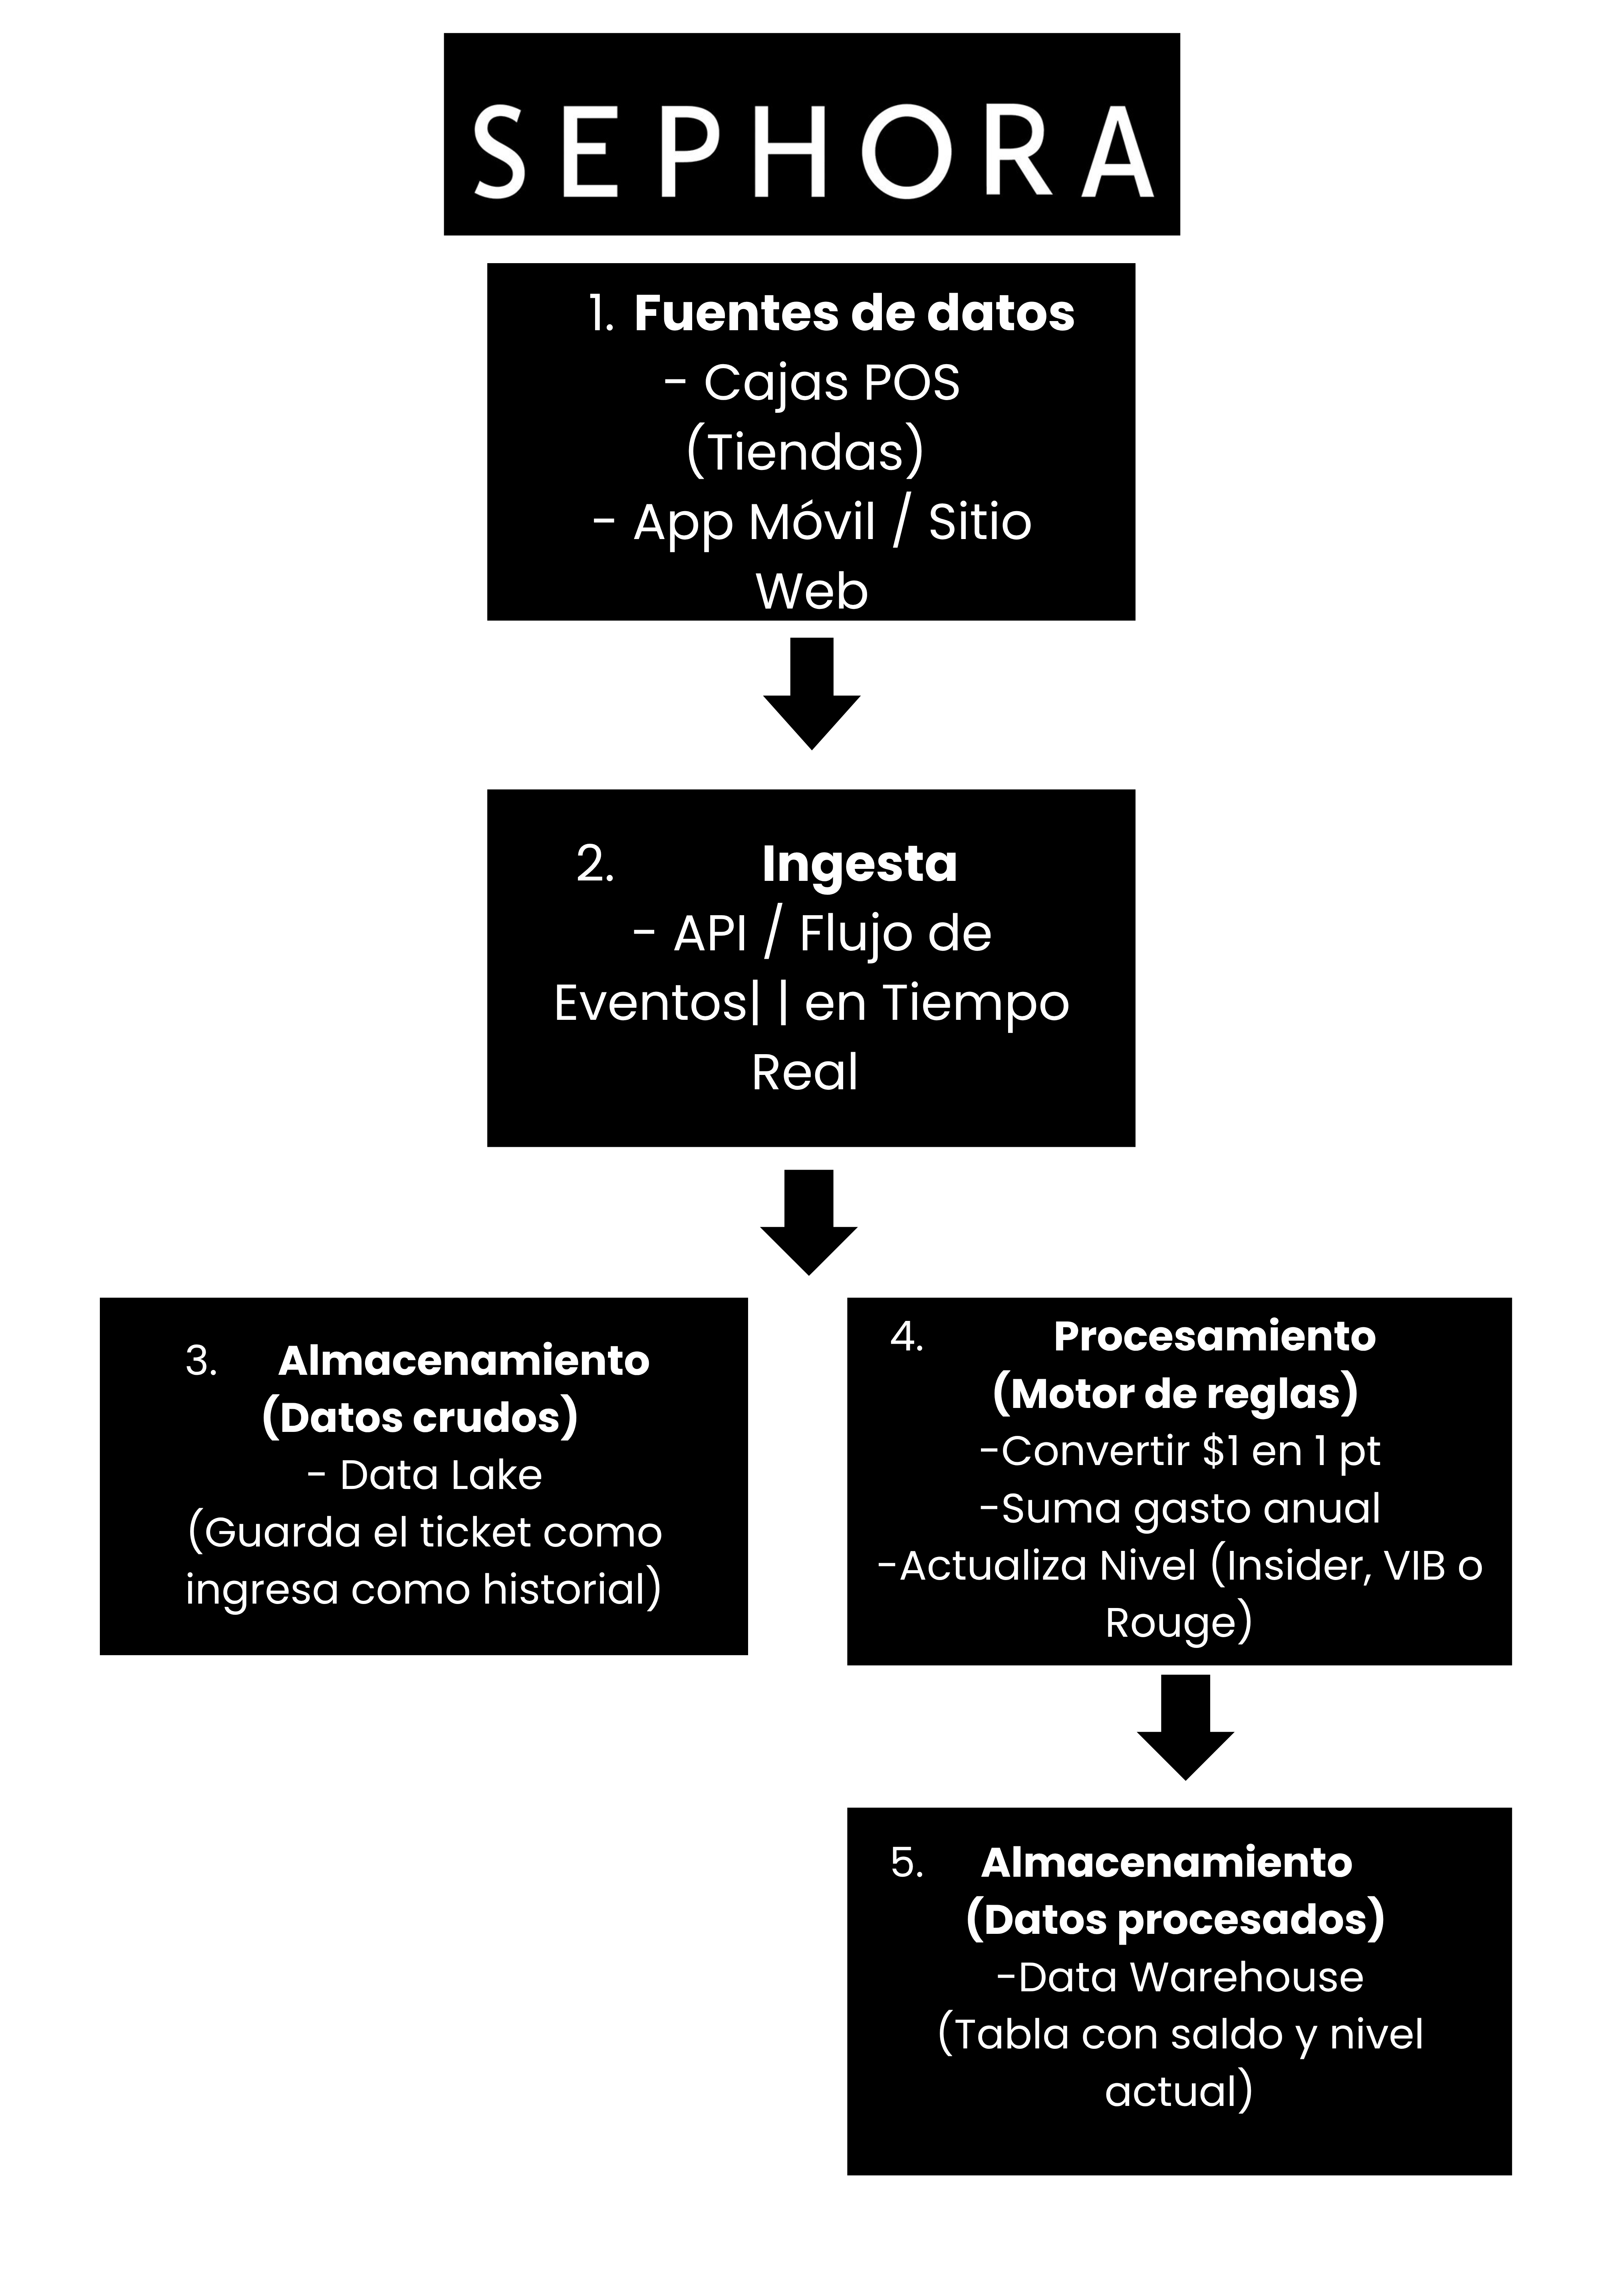

## 3. Código/procedimiento de una prueba funcional (POC) del sistema de puntos

### Paso 1: Extracción (Generación) de Datos
Para esta primera parte se simuló la información de origen de Sephora. Se utilizó la librería Pandas para generar:
1. Una tabla maestra de usuarios (Data Warehouse).
2. Una tabla de transacciones entrantes (Data Lake) simulando compras recientes.


In [ ]:
import pandas as pd

#crea la tabla maestra de Usuarios
#incluye los niveles definidos por la empresa: Insider, VIB y Rouge
datos_usuarios = {
    'id_usuario': [101, 102, 103, 104],
    'nombre': ['Ana', 'Carlos', 'Beatriz', 'David'],
    'saldo_puntos': [150, 300, 50, 950],
    'gasto_anual': [150.0, 300.0, 50.0, 950.0],
    'nivel': ['Insider', 'Insider', 'Insider', 'Insider'] #todos empiezan como insider para simular que subirán de nivel
}
df_usuarios = pd.DataFrame(datos_usuarios)

#crea la tabla de transacciones entrantes (Data Lake simulado)
#registra las compras recientes que acaban de entrar por la Ingesta
datos_transacciones = {
    'id_transaccion': [1, 2, 3, 4, 5],
    'id_usuario': [101, 103, 102, 104, 101],
    'monto_gastado': [50.0, 120.0, -20.0, 80.0, 30.0]
}
df_transacciones = pd.DataFrame(datos_transacciones)

#muestra las tablas para verificar que se crearon correctamente
print("Tabla Maestra de Usuarios")
print(df_usuarios)
print("Tabla de Transacciones Entrantes")
print(df_transacciones)


#exportar los DataFrames a archivos CSV físicos
df_usuarios.to_csv('tabla_maestra_usuarios.csv', index=False)
df_transacciones.to_csv('transacciones_entrantes.csv', index=False)

print("\n¡Archivos CSV generados y guardados con éxito!")

Tabla Maestra de Usuarios
   id_usuario   nombre  saldo_puntos  gasto_anual    nivel
0         101      Ana           150        150.0  Insider
1         102   Carlos           300        300.0  Insider
2         103  Beatriz            50         50.0  Insider
3         104    David           950        950.0  Insider
Tabla de Transacciones Entrantes
   id_transaccion  id_usuario  monto_gastado
0               1         101           50.0
1               2         103          120.0
2               3         102          -20.0
3               4         104           80.0
4               5         101           30.0

¡Archivos CSV generados y guardados con éxito!


### Paso 2: Limpieza y Filtrado (Data Quality)
Antes de que el motor de procesamiento calcule los puntos, hay que asegurar la calidad de los datos. En este paso, se filtró el Data Lake para descartar problemas  que podrían romper la lógica (como transacciones con montos negativos o en cero).

In [ ]:
#aplicar un filtro de calidad de datos
#conserva únicamente las transacciones donde el monto gastado sea mayor a 0
df_transacciones_limpias = df_transacciones[df_transacciones['monto_gastado'] > 0].copy()

print("Tabla de Transacciones Limpias")
print(df_transacciones_limpias)

#muestra cuántas transacciones se descartaron
descartadas = len(df_transacciones) - len(df_transacciones_limpias)
print(f"\nReporte de Calidad: Se descartaron {descartadas} transacciones")

Tabla de Transacciones Limpias
   id_transaccion  id_usuario  monto_gastado
0               1         101           50.0
1               2         103          120.0
3               4         104           80.0
4               5         101           30.0

Reporte de Calidad: Se descartaron 1 transacciones



* **Filtrado Exitoso:** El filtro identificó y eliminó correctamente la Transacción #3, la cual contenía un valor de -20.0.


### Paso 3: Procesamiento
En esta fase, se simuló el componente de Procesamiento de la Arquitectura de Datos. El motor leerá cada transacción ya filtrada (limpia) y aplicará las siguientes reglas del programa de Sephora:
1. **Acumulación Base:** Se suma 1 punto al saldo por cada \$1 gastado.
2. **Gasto Anual:** El monto de la transacción se suma al historial de gasto anual del cliente.
3. **Ascenso de Nivel:** Si el gasto anual acumulado alcanza los \$350, el cliente sube a VIB. Si alcanza los \$1000, sube al nivel máximo (Rouge).

In [ ]:
#función para procesar transacciones y actualizar la base de datos maestra
def procesar_transacciones(df_usuarios_actual, df_transacciones_nuevas):
    #hace una copia para no modificar los datos originales directamente
    df_actualizado = df_usuarios_actual.copy()

    #itera sobre cada transacción limpia que acaba de entrar
    for index, row in df_transacciones_nuevas.iterrows():
        id_usuario = row['id_usuario']
        monto = row['monto_gastado']

        #busca el índice del usuario en la tabla maestra
        usuario_idx = df_actualizado.index[df_actualizado['id_usuario'] == id_usuario].tolist()

        if usuario_idx:
            idx = usuario_idx[0]

            #aplica la regla base: $1 = 1 punto
            df_actualizado.at[idx, 'saldo_puntos'] += monto

            #suma al gasto anual acumulado
            nuevo_gasto_anual = df_actualizado.at[idx, 'gasto_anual'] + monto
            df_actualizado.at[idx, 'gasto_anual'] = nuevo_gasto_anual

            #acualiza el nivel
            if nuevo_gasto_anual >= 1000.0:
                df_actualizado.at[idx, 'nivel'] = 'Rouge'
            elif nuevo_gasto_anual >= 350.0:
                df_actualizado.at[idx, 'nivel'] = 'VIB'

    return df_actualizado

#ejecuta el motor de procesamiento uniendo ambas tablas
df_usuarios_final = procesar_transacciones(df_usuarios, df_transacciones_limpias)

print("Tabla maestra de usuarios (data Warehouse Actualizado)")
print(df_usuarios_final)

# Simulación de guardado en el data Warehouse
df_usuarios_final.to_csv('data_warehouse_usuarios.csv', index=False)

Tabla maestra de usuarios (data Warehouse Actualizado)
   id_usuario   nombre  saldo_puntos  gasto_anual    nivel
0         101      Ana           230        230.0  Insider
1         102   Carlos           300        300.0  Insider
2         103  Beatriz           170        170.0  Insider
3         104    David          1030       1030.0    Rouge




## 4. Conclusiones y Propuestas de Optimización del sistema
Como conclusión general del Caso de Estudio, la simulación demostró que es indispensable mantener filtros estrictos de calidad de datos (Data Quality) antes de la fase de procesamiento, detectar y aislar proactivamente transacciones erróneas, como aquellas con montos negativos, es vital para prevenir la corrupción de la base de datos principal. Asimismo, como propuesta de optimización para el sistema, se recomienda transicionar la arquitectura hacia un modelo de procesamiento en tiempo real (streaming), lo cual garantizará una mejor experiencia de usuario al permitir que los clientes vean reflejados sus puntos y sus ascensos de nivel en la aplicación móvil de manera instantánea justo después de realizar su compra en caja.




## 5. Garantización de ciberseguridad del sistema
Para proteger la integridad de la arquitectura de datos, es necesario establecer una barrera de seguridad durante la fase de Ingesta. Se recomienda la implementación de un sistema de autenticación estricto en las cajas POS que bloquee automáticamente el acceso a credenciales por defecto o altamente vulnerables. Esta medida preventiva funciona como la primera línea de defensa para garantizar que únicamente el personal autorizado pueda procesar transacciones, evitando así la manipulación malintencionada de los saldos de puntos en el Data Warehouse.


Adicionalmente, para proteger las cuentas de los clientes y garantizar que al momento de canjear puntos la solicitud provenga del usuario legítimo, se debe implementar una capa de seguridad en la aplicación móvil y el sitio web. Se recomienda integrar herramientas de análisis de comportamiento (como reCAPTCHA) para bloquear tráfico de bots, sumado a un sistema de Autenticación Multifactor (MFA) en transacciones críticas. Exigir validación biométrica (como Face ID o huella digital) o el ingreso de un código de seguridad de un solo uso (OTP) enviado al teléfono o correo del cliente antes de confirmar el canje, asegurará que los puntos sean utilizados exclusivamente por su dueño.


Finalmente, para garantizar la disponibilidad y recuperación de la información ante cualquier fallo técnico o incidente de seguridad, se recomienda implementar una política automatizada de copias de seguridad periódicas. Mantener respaldos constantes tanto del historial de transacciones crudas (Data Lake) como de los saldos y niveles procesados (Data Warehouse) asegurará que el sistema pueda ser restaurado rápidamente en caso de un problema, minimizando la pérdida de datos y protegiendo las recompensas acumuladas por los clientes.

## 6. Referencias
https://www.sephora.com/BeautyInsider
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

## 7. Repositorio
* **Link de GitHub:** https://github.com/sofiabilbaocr/Intro-a-datos